In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


- Qual a classe que os passageiros mais sobreviveram?
- Qual a faixa etária que os passageiros mais sobreviveram?
- Se foi respeitado a regra de salvamento (crianças, idosos, mulheres, homens)
- Há influência entre o porto de embarque e a taxa de sobrevivência?

In [4]:
df.Sex.value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   PassengerId   891 non-null    int64   
 1   Survived      891 non-null    int64   
 2   Pclass        891 non-null    int64   
 3   Name          891 non-null    object  
 4   Sex           891 non-null    object  
 5   Age           891 non-null    float64 
 6   SibSp         891 non-null    int64   
 7   Parch         891 non-null    int64   
 8   Ticket        891 non-null    object  
 9   Fare          891 non-null    float64 
 10  Cabin         204 non-null    object  
 11  Embarked      889 non-null    object  
 12  faixa_etaria  891 non-null    category
dtypes: category(1), float64(2), int64(5), object(5)
memory usage: 84.7+ KB


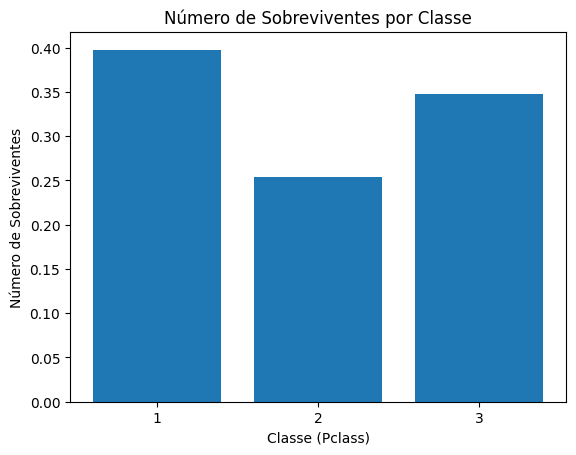

In [6]:
Survived_Pclass = df.groupby(['Survived', 'Pclass']).size()

# Filtra os dados para Survived = 1
sobreviventes_por_classe = Survived_Pclass[1]

# Cria o gráfico de barras
plt.bar(sobreviventes_por_classe.index, (sobreviventes_por_classe.values / 342))
plt.xlabel('Classe (Pclass)')
plt.ylabel('Número de Sobreviventes')
plt.title('Número de Sobreviventes por Classe')
plt.xticks(sobreviventes_por_classe.index)
plt.show()

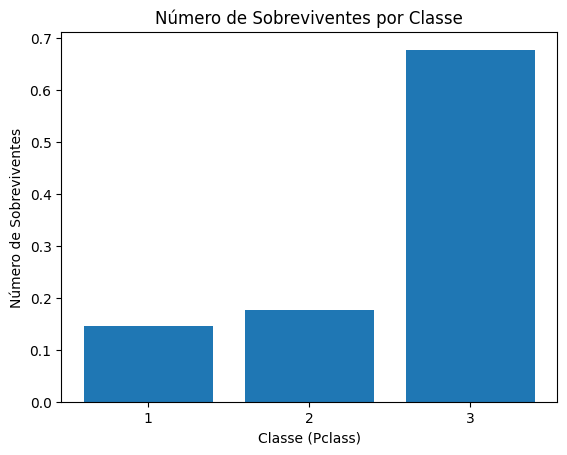

In [7]:
# Filtra os dados para Survived = 0
sobreviventes_por_classe = Survived_Pclass[0]

# Cria o gráfico de barras
plt.bar(sobreviventes_por_classe.index, (sobreviventes_por_classe.values / 549))
plt.xlabel('Classe (Pclass)')
plt.ylabel('Número de Sobreviventes')
plt.title('Número de Sobreviventes por Classe')
plt.xticks(sobreviventes_por_classe.index)
plt.show()

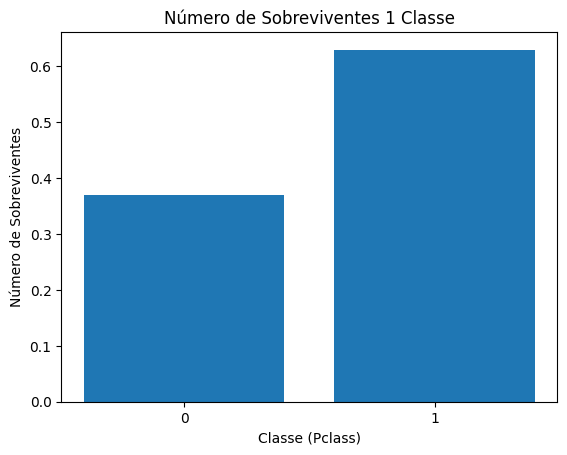

In [8]:
Survived_Pclass = df.groupby(['Pclass', 'Survived']).size()
# Filtra os dados para Survived = 0
sobreviventes_por_classe = Survived_Pclass[1]

# Cria o gráfico de barras
plt.bar(sobreviventes_por_classe.index, (sobreviventes_por_classe.values / 216))
plt.xlabel('Classe (Pclass)')
plt.ylabel('Número de Sobreviventes')
plt.title('Número de Sobreviventes 1 Classe')
plt.xticks(sobreviventes_por_classe.index)
plt.show()

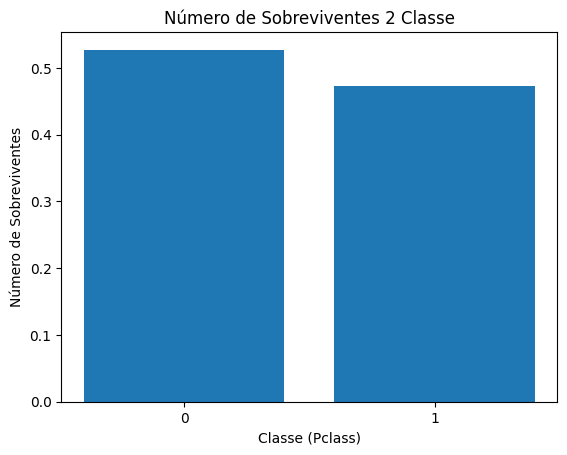

In [9]:
# Filtra os dados para Survived = 0
sobreviventes_por_classe = Survived_Pclass[2]

# Cria o gráfico de barras
plt.bar(sobreviventes_por_classe.index, (sobreviventes_por_classe.values / 184))
plt.xlabel('Classe (Pclass)')
plt.ylabel('Número de Sobreviventes')
plt.title('Número de Sobreviventes 2 Classe')
plt.xticks(sobreviventes_por_classe.index)
plt.show()

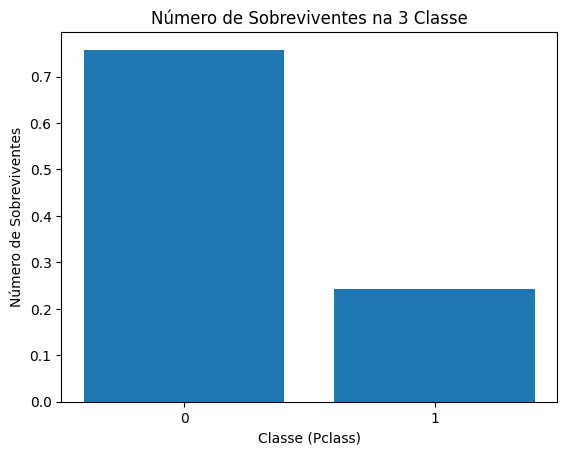

In [39]:
# Filtra os dados para Survived = 0
sobreviventes_por_classe = Survived_Pclass[3]

# Cria o gráfico de barras
plt.bar(sobreviventes_por_classe.index, (sobreviventes_por_classe.values / 491))
plt.xlabel('Classe (Pclass)')
plt.ylabel('Número de Sobreviventes')
plt.title('Número de Sobreviventes na 3 Classe')
plt.xticks(sobreviventes_por_classe.index)
plt.show()

In [11]:
media_idade_mulheres = df[df['Sex'] == 'female']['Age'].mean()
media_idade_homens = df[df['Sex'] == 'male']['Age'].mean()
df['Age'] = df.apply(lambda row: media_idade_homens if pd.isnull(row['Age']) and row['Sex'] == 'male' else (media_idade_mulheres if pd.isnull(row['Age']) and row['Sex'] == 'female' else row['Age']), axis=1)

In [12]:
pd.pivot_table(data=df, values='Age', index='Sex', aggfunc='mean')

,Age
Sex,
female,27.915709
male,30.726645


In [13]:
faixas_etarias = pd.cut(df['Age'], bins=[0, 18, 30, 50, 100], labels=['0-17','18-29','30-49','50+'])
df["faixa_etaria"] = faixas_etarias
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,faixa_etaria
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,18-29
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,30-49
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,18-29
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,30-49
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,30-49
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S,18-29
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,18-29
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,27.915709,1,2,W./C. 6607,23.4500,NaN,S,18-29
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,18-29


In [14]:
df.faixa_etaria.value_counts()

faixa_etaria
30-49    365
18-29    323
0-17     139
50+       64
Name: count, dtype: int64

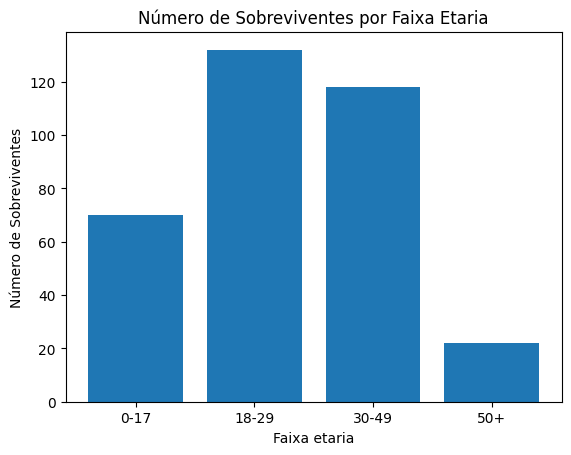

In [15]:
Survived_FE = df.groupby(['Survived', 'faixa_etaria']).size()

# Filtra os dados para Survived = 1
sobreviventes_por_faixa = Survived_FE[1]

# Cria o gráfico de barras
plt.bar(sobreviventes_por_faixa.index, (sobreviventes_por_faixa.values))
plt.xlabel('Faixa etaria')
plt.ylabel('Número de Sobreviventes')
plt.title('Número de Sobreviventes por Faixa Etaria')
plt.xticks(sobreviventes_por_faixa.index)
plt.show()

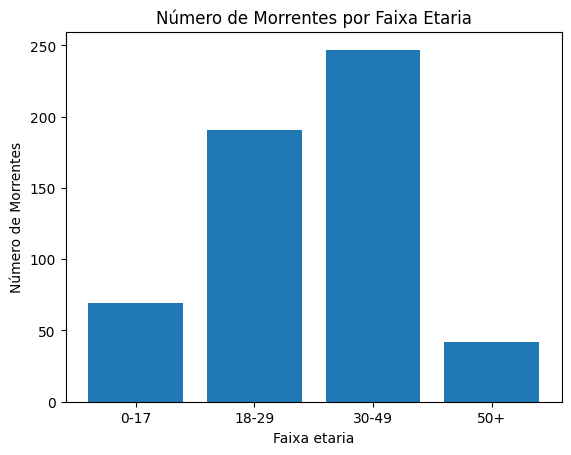

In [16]:
Survived_FE = df.groupby(['Survived', 'faixa_etaria']).size()

# Filtra os dados para Survived = 1
sobreviventes_por_faixa = Survived_FE[0]

# Cria o gráfico de barras
plt.bar(sobreviventes_por_faixa.index, (sobreviventes_por_faixa.values))
plt.xlabel('Faixa etaria')
plt.ylabel('Número de Morrentes')
plt.title('Número de Morrentes por Faixa Etaria')
plt.xticks(sobreviventes_por_faixa.index)
plt.show()

In [17]:
pd.pivot_table(data=df, values='Survived', index='faixa_etaria', aggfunc=['sum', 'count'])

,sum,count
,Survived,Survived
faixa_etaria,,
0-17,70,139
18-29,132,323
30-49,118,365
50+,22,64


In [18]:
Survived_FE = df.groupby(['faixa_etaria', 'Sex', 'Survived']).size()
Survived_FE

faixa_etaria  Sex     Survived
0-17          female  0            22
                      1            46
              male    0            47
                      1            24
18-29         female  0            39
                      1           104
              male    0           152
                      1            28
30-49         female  0            19
                      1            67
              male    0           228
                      1            51
50+           female  0             1
                      1            16
              male    0            41
                      1             6
dtype: int64

In [19]:
import plotly.express as px

# Agrupa os dados para calcular o tamanho das bolhas
df_grouped = df.groupby(['Survived', 'faixa_etaria', 'Sex']).size().reset_index(name='Count')

# Converte a coluna 'AgeGroup' para string antes de plotar
df_grouped['faixa_etaria'] = df_grouped['faixa_etaria'].astype(str)  # Converte Interval para string

# Cria o gráfico de bolhas
fig = px.scatter(df_grouped, x='faixa_etaria', y='Sex', size='Count', color='Survived',
                 hover_name='faixa_etaria', labels={'Sex': 'Sexo', 'Survived': 'Sobreviveu'},
                 title='Relação entre Idade, Sexo e Sobrevivência no Titanic')

# Personaliza o layout
fig.update_layout(xaxis_title='Grupo de Idade', yaxis_title='Sexo (0=Feminino, 1=Masculino)')

# Exibe o gráfico
fig.show()

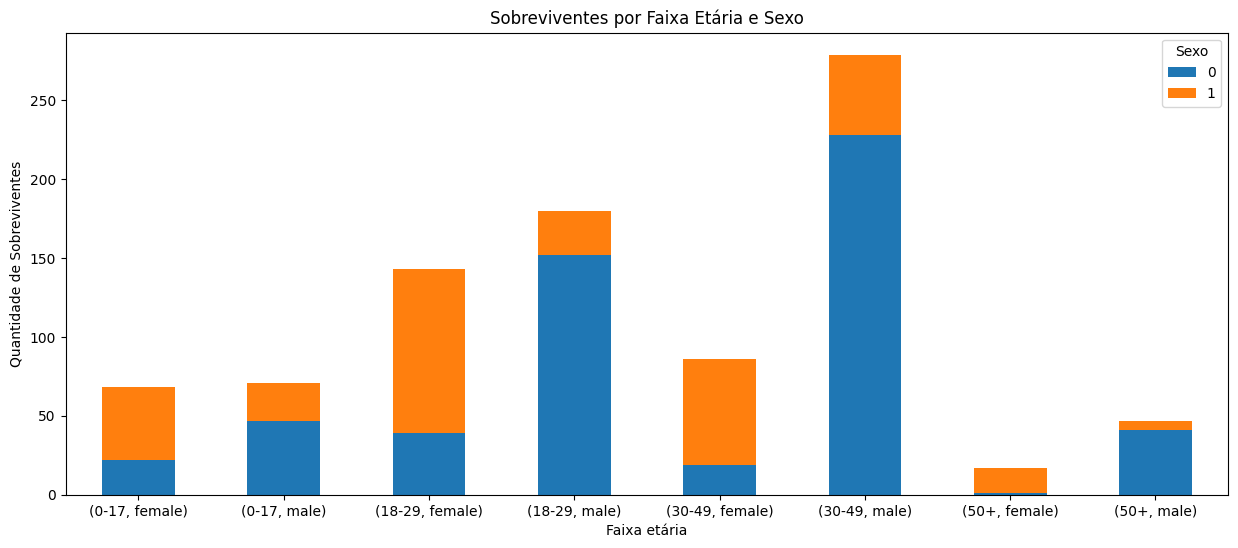

In [32]:
"""age_survival = df.groupby(['faixa_etaria', 'Survived', 'Sex'])['Survived'].count().unstack()

# Plota o gráfico de barras
age_survival.plot(kind='bar', stacked=True)
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Passageiros')
plt.title('Sobrevivência por Faixa Etária')
plt.legend(['Não Sobreviveu', 'Sobreviveu'])
plt.show()"""

# Filtra os dados para Survived == 1


# Agrupa os dados para calcular a contagem de sobreviventes por faixa etária e sexo
survival = df.groupby(['faixa_etaria', 'Sex', 'Survived'])['Survived'].count().unstack()

# Calcule o total de sobreviventes para cada grupo de faixa etária
total_sobreviventes = survival.sum(axis=1)

# Calcule a porcentagem de sobreviventes para cada grupo de faixa etária e sexo
survival_porcentagem = survival.div(total_sobreviventes, axis=0) * 100

# Plota o gráfico de barras
x = df.faixa_etaria
survival.plot(kind='bar', stacked=True,figsize=(15, 6))
plt.xlabel('Faixa etária')
plt.ylabel('Quantidade de Sobreviventes')
plt.title('Sobreviventes por Faixa Etária e Sexo')
plt.legend(title='Sexo')
plt.xticks(rotation=0)
_ = plt.legend(title='Sexo')

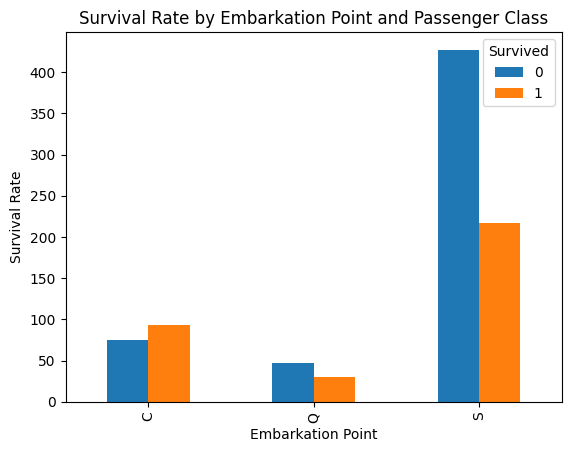

In [23]:
#Há influência entre o porto de embarque e a taxa de sobrevivência?
# Group the data by embarkation point and passenger class, and calculate survival rates
#survival_rates = df.groupby(['Embarked', 'Pclass'])['Survived'].mean().unstack()
survival_rates = df.groupby(['Embarked', 'Survived'])['Survived'].count().unstack()
# Create a grouped bar chart
survival_rates.plot(kind='bar')
plt.xlabel('Embarkation Point')
plt.ylabel('Survival Rate')
_ = plt.title('Survival Rate by Embarkation Point and Passenger Class')

In [99]:
embarked_mapping = {'S': 1, 'Q': 2, 'C': 3}
faixa_etaria_mapping = {'0-17': 1, '18-29': 2, '30-49': 3, '50+': 4}

df2 = df[['Pclass', 'Sex', 'Embarked','faixa_etaria', 'Survived']]

df2.dropna(inplace=True)
df2['Embarked_num'] = df2['Embarked'].map(embarked_mapping)
df2['faixa_etaria_num'] = df2['faixa_etaria'].map(faixa_etaria_mapping)
df2['Sex_bool'] = df2['Sex'].map({'female': 0, 'male': 1})

df2
#sns.pairplot(data=df2)

<ipython-input-99-b3cc7c3d67f5>:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-99-b3cc7c3d67f5>:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-99-b3cc7c3d67f5>:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-99-b3cc7c3d67f5>:9: SettingWithCopyWarning:


A value is trying to 

,Pclass,Sex,Embarked,faixa_etaria,Survived,Embarked_num,faixa_etaria_num,Sex_bool
0,3,male,S,18-29,0,1,2,1
1,1,female,C,30-49,1,3,3,0
2,3,female,S,18-29,1,1,2,0
3,1,female,S,30-49,1,1,3,0
4,3,male,S,30-49,0,1,3,1
...,...,...,...,...,...,...,...,...
886,2,male,S,18-29,0,1,2,1
887,1,female,S,18-29,1,1,2,0
888,3,female,S,18-29,0,1,2,0
889,1,male,C,18-29,1,3,2,1


In [100]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Pclass            889 non-null    int64   
 1   Sex               889 non-null    object  
 2   Embarked          889 non-null    object  
 3   faixa_etaria      889 non-null    category
 4   Survived          889 non-null    int64   
 5   Embarked_num      889 non-null    int64   
 6   faixa_etaria_num  889 non-null    category
 7   Sex_bool          889 non-null    int64   
dtypes: category(2), int64(4), object(2)
memory usage: 50.8+ KB


In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [101]:
X = df2.drop(['Survived','Embarked', 'Sex', 'faixa_etaria'], axis=1)
y = df2['Survived']
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)


In [102]:
#Treinamento
rfc = RandomForestClassifier(random_state = 42)
modelo = rfc.fit(xtrain, ytrain)

In [103]:
#Teste
y_pred = modelo.predict(xtest)
predAll = modelo.predict(X)
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       167
           1       0.83      0.62      0.71       100

    accuracy                           0.81       267
   macro avg       0.81      0.77      0.78       267
weighted avg       0.81      0.81      0.80       267



  - Com as variáveis Embarked_num, Sex_bool, Pclass, Age e Survived, Accuracy = 0.81
  - Com as variáveis Embarked_num, Sex_bool, Pclass, Age, Survived, Parch, SibSp Accuracy = 0.78
  - Com as variáveis Embarked_num, Sex_bool, Pclass, Age, Survived, SibSp Accuracy = 0.79
  - Com as variáveis Embarked_num, Sex_bool, Pclass, Age, Survived, Parch Accuracy = 0.78
  - Com as variáveis Sex_bool, Pclass, Age e Survived, Accuracy = 0.78    

In [77]:
fig = px.imshow(confusion_matrix(ytest, y_pred), x=modelo.classes_, y=modelo.classes_)
fig.show()